<a href="https://colab.research.google.com/github/rishikumar74/deeplearning/blob/main/rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **RECURRENT NEURAL NETWORK**

In [1]:

from google.colab import drive
import pandas as pd


drive.mount('/content/drive')


df = pd.read_csv('/content/optimized_waste_management_data.csv')
df.head()

Mounted at /content/drive


,date,waste_volume,organic_waste,recyclable_waste,hazardous_waste,collection_frequency,landfill_capacity_used,recycling_rate
0,01-01-2020,48.85,31.49,12.55,4.81,Weekly,55.87,47.37
1,02-01-2020,49.45,29.76,14.76,4.94,Weekly,51.91,41.70
2,03-01-2020,51.03,32.29,13.65,5.09,Bi-weekly,53.08,58.73
3,04-01-2020,54.70,35.09,14.36,5.25,Bi-weekly,52.04,39.34
4,05-01-2020,51.74,29.99,16.87,4.88,Bi-weekly,48.01,40.45


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense


In [3]:
df.head(5
        )

,date,waste_volume,organic_waste,recyclable_waste,hazardous_waste,collection_frequency,landfill_capacity_used,recycling_rate
0,01-01-2020,48.85,31.49,12.55,4.81,Weekly,55.87,47.37
1,02-01-2020,49.45,29.76,14.76,4.94,Weekly,51.91,41.70
2,03-01-2020,51.03,32.29,13.65,5.09,Bi-weekly,53.08,58.73
3,04-01-2020,54.70,35.09,14.36,5.25,Bi-weekly,52.04,39.34
4,05-01-2020,51.74,29.99,16.87,4.88,Bi-weekly,48.01,40.45


In [4]:
df.isnull().sum()

,0
date,0
waste_volume,0
organic_waste,0
recyclable_waste,0
hazardous_waste,0
collection_frequency,0
landfill_capacity_used,0
recycling_rate,0


In [5]:
df.shape

(1461, 8)

In [6]:
df['collection_frequency'].value_counts()

,count
collection_frequency,
Bi-weekly,786
Weekly,675


In [7]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['collection_frequency']=le.fit_transform(df['collection_frequency'])

In [8]:
df.head()


,date,waste_volume,organic_waste,recyclable_waste,hazardous_waste,collection_frequency,landfill_capacity_used,recycling_rate
0,01-01-2020,48.85,31.49,12.55,4.81,1,55.87,47.37
1,02-01-2020,49.45,29.76,14.76,4.94,1,51.91,41.70
2,03-01-2020,51.03,32.29,13.65,5.09,0,53.08,58.73
3,04-01-2020,54.70,35.09,14.36,5.25,0,52.04,39.34
4,05-01-2020,51.74,29.99,16.87,4.88,0,48.01,40.45


In [9]:
#extract features to predict
#we only use the wate col for forecasting
waste_data=df[['waste_volume']]
waste_data

,waste_volume
0,48.85
1,49.45
2,51.03
3,54.70
4,51.74
...,...
1456,55.85
1457,52.84
1458,59.21
1459,53.66


In [10]:
#Normalize the data using minmaxScaler(0-1)
sc=MinMaxScaler()
scaled_data=sc.fit_transform(waste_data)

In [13]:
scaled_data


array([[0.47691575],
       [0.49119467],
       [0.52879581],
       ...,
       [0.72346502],
       [0.59138505],
       [0.59043313]])

In [15]:
#convert data into sequence
#rnn requires sequencial output
#eg:previous 10 days--->predict next day
def create_sequence(data,seq_length) :
  x=[]
  y=[]
  for i in range(len(data)-seq_length) :
    x.append(data[i:i+seq_length])
    y.append(data[i+seq_length])
  return np.array(x),np.array(y)


In [16]:
#create time sequences
sequence_length=10
x,y=create_sequence(scaled_data,sequence_length)

print(x.shape)
print(y.shape)



(1451, 10, 1)
(1451, 1)


In [19]:
from matplotlib.cbook import simple_linear_interpolation
#build the rnn model
#arch:input-->rnn layer--->dense output
model=Sequential()
model.add(SimpleRNN(50,activation='tanh', input_shape=(sequence_length, 1)))
#simpleRnn(50)
#50 neurons
#tanh activation
#input shape=(10 time steps,1 feature)
model.add(Dense(1))#one value->next day waste

In [20]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
split=int(0.8*len(x))
x_train=x[:split]
x_test=x[split:]

y_train=y[:split]
y_test=y[split:]


In [23]:
# train the model for 50 epochs
history=model.fit(
    x_train,y_train,epochs=50,batch_size=16,validation_split=0.1
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0579 - val_loss: 0.0146
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0111 - val_loss: 0.0140
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0098 - val_loss: 0.0145
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0096 - val_loss: 0.0122
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0094 - val_loss: 0.0116
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0093 - val_loss: 0.0122
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0096 - val_loss: 0.0161
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0095 - val_loss: 0.0116
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0100 - val_loss: 0.0122
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0093 - val_loss: 0.0121
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0094 - val_loss: 0.0115
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0101 - val_l

In [24]:
#evaluate the model
loss=model.evaluate(x_test,y_test)
print("Test loss",loss)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0095 
Test loss 0.009504505433142185


In [25]:
predictions=model.predict(x_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [30]:
#convert predictions back to original scale
predictions =sc.inverse_transform(predictions)
y_test_actual=sc.inverse_transform(y_test)

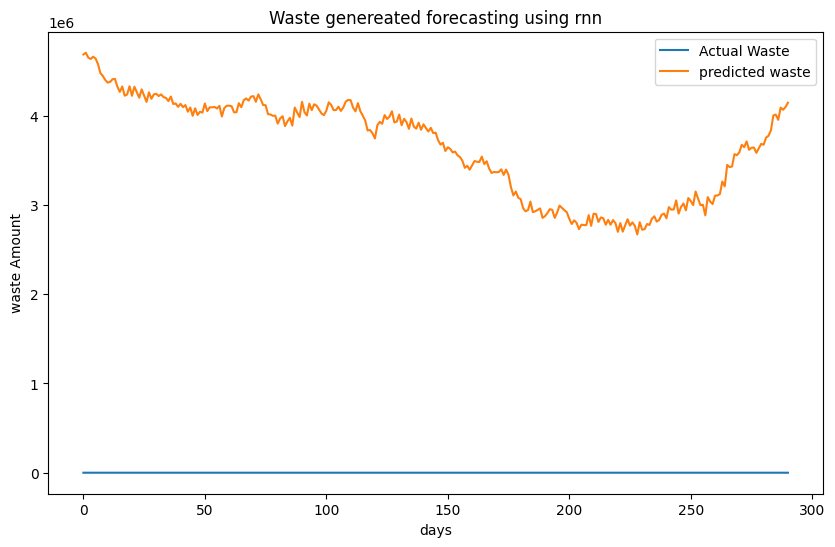

In [31]:
#plot predictions vs acual values
plt.figure(figsize=(10,6))
plt.plot(y_test_actual,label='Actual Waste')
plt.plot(predictions,label="predicted waste")

plt.title("Waste genereated forecasting using rnn")
plt.xlabel('days')
plt.ylabel('waste Amount')
plt.legend()
plt.show()
